# APR + Fit Workflow

Full pipeline: Adaptive Pixel Reassignment (APR) followed by per-pixel
exponential lifetime estimation via IRF-convolved model fitting.

**Steps**
1. Calibrate the raw `.h5` acquisition file
2. Load calibrated data and metadata
3. Inspect photon flux per SPAD channel
4. *(optional)* Apply APR — pixel reassignment overwrites `data_input` in memory
5. Visualise raw vs. reassigned intensity
6. Sum channels applying calibration timing shifts
7. Preview single-pixel fit
8. Run per-pixel fit to generate lifetime maps
9. Visualise and export results


## Imports

In [1]:
from pathlib import Path
import importlib
import sys

# ── Locate repository root (contains 'src/') ──────────────────────────────
ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SRC = str(ROOT / "src")
if SRC in sys.path:
    sys.path.remove(SRC)
sys.path.insert(0, SRC)

# ── Optional sibling repo: BrightEyes-MCS-File ────────────────────────────
MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists():
    MCS_FILE_SRC_STR = str(MCS_FILE_SRC)
    if MCS_FILE_SRC_STR in sys.path:
        sys.path.remove(MCS_FILE_SRC_STR)
    sys.path.insert(0, MCS_FILE_SRC_STR)

import h5py
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# APR
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.Graph_lib as gr

# Calibration & alignment
import brighteyes_mcs_file.alignment as alignment_module
alignment_module = importlib.reload(alignment_module)

from brighteyes_mcs_file.alignment import Alignment
from brighteyes_mcs_file import (
    calibrate_h5_file,
    show_h5_structure_html,
    sum_channel_applying_shifts,
)

# Graph tools
import brighteyes_flim.graph_tools as graph
graph = importlib.reload(graph)


/home/morlando1-iit.local/manuel/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

Edit only this cell before running the notebook.

| Parameter | Description |
|---|---|
| `FILE_REFERENCE` | Path to the IRF / reference `.h5` file used for calibration |
| `FILE_DATA` | Path to the raw acquisition `.h5` file |
| `DATA_KEY` | HDF5 dataset key for the detector signal (`"data"` or `"data_channels_extra"`) |
| `TAU_REF` | Known lifetime of the reference sample (ns) |
| `DO_APR` | Set `True` to apply Adaptive Pixel Reassignment before fitting |
| `ROI` | Pixel crop `(row_start, row_end, col_start, col_end)` — `None` for full FOV |
| `REF_CHANNEL` | Central detector element index used as APR reference (typically 12 for 5×5) |
| `USF` | Up-sampling factor for sub-pixel shift estimation |
| `REASSIGN_MODE` | `'interp'` (bilinear, recommended) or `'fft'` (Fourier shift) |
| `FIT_INITIAL_TAU` | Initial guess for the fluorescence lifetime (ns) |
| `THRESHOLD` | Minimum intensity fraction below which pixels are masked |
| `LIFETIME_BOUNDS` | `[min, max]` display range for the lifetime colourmap (ns) |


In [ ]:
# ── File paths ────────────────────────────────────────────────────────────
FILE_REFERENCE = r'/home/morlando1-iit.local/manuel/18052026_flim/FLIMLabs.h5'
FILE_DATA      = r'/home/morlando1-iit.local/manuel/25052026_mito_tub_flim/25052026_tomm20_pxs100_0.h5'

DATA_KEY             = "data"   # "data" or "data_channels_extra"
CALIBRATION_PRODUCT  = {"data": "spad", "data_channels_extra": "aux"}[DATA_KEY]

# ── Calibration parameters ────────────────────────────────────────────────
TAU_REF          = 2.5          # known reference lifetime (ns)
REFERENCE_TYPE   = "ref"        # "ref" or "irf"
FIT_MODE         = "model_shift"
FIT_TYPE         = "likelihood"
LASER_FREQ_MHZ   = None
LASER_PERIOD_NS  = None
CHANNEL_SKEW_SOURCE = "ref"
OVERWRITE        = True

# ── APR parameters ────────────────────────────────────────────────────────
DO_APR        = True            # set False to skip reassignment
ROI           = None            # e.g. (1000, 1750, 1200, 1950), or None
REF_CHANNEL   = 12              # reference detector (centre of 5×5 array)
USF           = 100             # up-sampling factor for shift estimation
REASSIGN_MODE = "interp"        # "interp" or "fft"

# ── Fit parameters ────────────────────────────────────────────────────────
FIT_INITIAL_TAU = 4.0           # initial lifetime guess (ns)
FIT_INITIAL_dT  = 1.0           # initial IRF shift guess (ns)
FIT_INITIAL_C   = 1.0           # initial amplitude guess
FIT_MODE_PIXEL  = "irf_shift"   # convolution mode passed to perform_fit_data
FIT_TYPE_PIXEL  = "likelihood"  # "likelihood" or "leastsq"



## Calibration

`calibrate_h5_file` processes the raw HDF5 data file and writes a calibrated copy containing
the aligned per-channel IRF and reference traces, the per-channel timing offsets (channel skew),
and the laser timing parameters.
If `OVERWRITE = True` the calibration is recomputed even if a calibrated file already exists.

> **Note:** `channel_skew_fit_reference_channel=12` uses the central SPAD pixel as the timing
> reference. `channel_skew_fit_upsampling=10` enables sub-bin precision in the cross-correlation.


In [3]:
FILE_WITH_CALIBRATION = calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    overwrite=OVERWRITE,
)
print(FILE_WITH_CALIBRATION)


/home/morlando1-iit.local/manuel/25052026_mito_tub_flim/25052026_tomm20_pxs100_0_calib.h5


## Load Calibrated Data

All arrays and metadata are read from the calibrated HDF5 file.

| Variable | Shape | Description |
|---|---|---|
| `data_input` | `(rep, z, y, x, t_bins, channels)` | Raw photon counts |
| `channel_skew` | `(channels,)` | Per-channel timing offset [bins] |
| `irf_common_delay_realigned` | `(t_bins, channels)` | Aligned IRF traces |
| `ref_common_delay_realigned` | `(t_bins, channels)` | Aligned reference-dye traces |
| `laser_freq_mhz` | scalar | Laser repetition frequency [MHz] |
| `laser_period_ns` | scalar | Laser period [ns] |
| `nbin` | scalar | Number of TCSPC time bins per period |
| `pixel_size_x_um` | scalar | Lateral pixel size [µm] |
| `pxdwelltime` | scalar | Pixel dwell time [µs] |


In [4]:
with h5py.File(FILE_WITH_CALIBRATION, "r") as hf:
    calibration = hf[f"calibration/results/{CALIBRATION_PRODUCT}"]
    metadata    = hf["raw/metadata"]

    laser_freq_mhz  = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin            = int(metadata.attrs["time_bins"])
    pixel_size_x_um = float(metadata.attrs["pixel_size_x_um"])
    pxdwelltime     = float(metadata.attrs["pixel_dwell_time_us"])

    # data_input shape: (rep, z, y, x, t_bins, channels)
    data_input                 = hf[f"raw/{CALIBRATION_PRODUCT}"][:]
    channel_skew               = calibration["timing/channel_skew_bins"][:]
    irf_common_delay_realigned = calibration["aligned/irf_trace"][:]

# Time axis in ns (used for fitting)
t = np.arange(nbin, dtype=float) * laser_period_ns / nbin

print(f"Laser timing : {laser_freq_mhz:.4f} MHz  ({laser_period_ns:.4f} ns period)")
print(f"data_input   : {data_input.shape}  (rep, z, y, x, t_bins, channels)")
print(f"t axis       : {t[0]:.3f} … {t[-1]:.3f} ns  ({nbin} bins)")


Laser timing : 40.0000 MHz  (25.0000 ns period)
data_input   : (1, 1, 512, 512, 91, 25)  (rep, z, y, x, t_bins, channels)
t axis       : 0.000 … 24.725 ns  (91 bins)


## Photon Flux Per SPAD Channel

Compute the total photon count and the average count rate (flux) for each SPAD channel.

In [5]:
n_foton_per_channel = np.sum(data_input, axis=(0, 1, 2, 3, 4))
n_rep, n_frame, nx, ny = (data_input.shape[i] for i in (0, 1, 2, 3))
n_px_total  = n_rep * n_frame * nx * ny
total_time_s = n_px_total * pxdwelltime * 1e-6

flux_per_channel = n_foton_per_channel / total_time_s   # shape: (n_channels,)
flux_total       = flux_per_channel.sum()

print(f"Pixel dwell time         : {pxdwelltime:.3f} µs")
print(f"Total acquisition time   : {total_time_s:.4f} s")
print(f"Total flux               : {flux_total * 1e-3:.2f} kHz")
print("\nFlux per channel (kHz):")
for i, val in enumerate(flux_per_channel, 1):
    print(f"{val * 1e-3:<8.2f}", end="" if i % 5 != 0 else "\n")


Pixel dwell time         : 182.000 µs
Total acquisition time   : 47.7102 s
Total flux               : 1714.43 kHz

Flux per channel (kHz):
39.24   52.23   60.24   51.09   35.88   
52.01   86.45   115.45  93.62   51.64   
81.95   104.85  147.30  115.86  61.51   
47.31   79.00   99.60   81.96   49.83   
33.80   45.38   51.08   44.39   32.76   


## APR — Pixel Reassignment *(optional)*

Controlled by `DO_APR` in the parameters cell.
When enabled, the shift vectors are estimated from the intensity image (sum over time bins)
and the reassignment is then applied **independently to each time bin**, fully preserving the
TCSPC decay information required for phasor analysis.

`data_input` is overwritten in memory with the spatially-reassigned array;
all downstream cells are unaffected.

Shift vectors are printed in **nanometres** for physical interpretability
(pixel size is read from the metadata).


Shift vectors (dy, dx) per channel [nm]:
[[-170.25440313 -171.23287671]
 [-143.83561644  -67.5146771 ]
 [-130.1369863     6.84931507]
 [-127.20156556   64.57925636]
 [-125.2446184   126.22309198]
 [ -70.45009785 -145.7925636 ]
 [ -61.64383562  -60.66536204]
 [ -65.55772994    3.91389432]
 [ -69.47162427   63.60078278]
 [ -75.34246575  124.26614481]
 [   7.82778865 -130.1369863 ]
 [   6.84931507  -62.6223092 ]
 [   0.            0.        ]
 [  -4.89236791   61.64383562]
 [ -12.72015656  122.30919765]
 [  75.34246575 -128.18003914]
 [  68.49315068  -65.55772994]
 [  64.57925636   -4.89236791]
 [  54.79452055   58.70841487]
 [  38.16046967  107.63209393]
 [ 183.95303327 -147.74951076]
 [ 145.7925636   -69.47162427]
 [ 130.1369863    -7.82778865]
 [ 110.56751468   46.9667319 ]
 [  65.55772994   73.38551859]]


/home/morlando1-iit.local/manuel/.venv/lib/python3.12/site-packages/brighteyes_ism/analysis/Graph_lib.py:550: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(shift[:, 0], shift[:, 1], s=80, c=color, edgecolors='black', cmap=cmap)


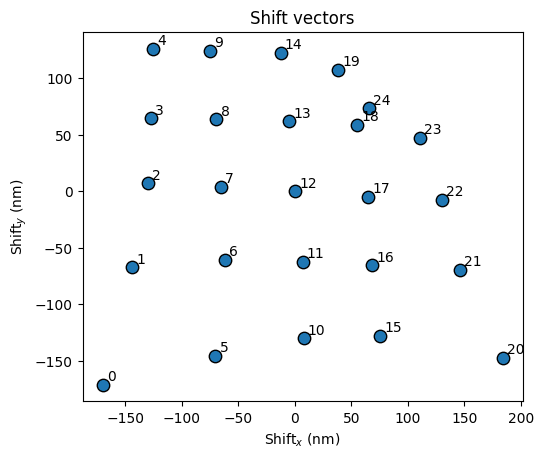

Reassigning time bins: 100%|██████████| 91/91 [01:04<00:00,  1.42it/s]

APR complete — data_input shape: (1, 1, 512, 512, 91, 25)


In [6]:
if DO_APR:
    # Select first rep and z-plane → (y, x, t_bins, channels)
    image_4D = data_input[0, 0, ...]

    # Apply spatial crop if requested
    if ROI is not None:
        r0, r1, c0, c1 = ROI
        image_4D = image_4D[r0:r1, c0:c1, ...]
        print(f"ROI applied — cropped shape: {image_4D.shape}")

    # Intensity image (y, x, channels) — used only for shift estimation
    image_intensity = np.sum(image_4D, axis=-2)

    # Estimate sub-pixel shift vectors
    shift_vectors, estimation_error = apr.ShiftVectors(
        image_intensity, usf=USF, ref=REF_CHANNEL
    )

    pixel_size_nm    = pixel_size_x_um * 1000
    shift_vectors_nm = shift_vectors * pixel_size_nm

    print("Shift vectors (dy, dx) per channel [nm]:")
    print(shift_vectors_nm)
    gr.PlotShiftVectors(shift_vectors_nm)
    plt.show()

    # Reassign each time bin independently
    n_y, n_x, n_bins, n_ch = image_4D.shape
    reassigned = np.empty_like(image_4D, dtype=np.float32)

    for b in tqdm(range(n_bins), desc="Reassigning time bins"):
        reassigned[:, :, b, :] = apr.Reassignment(
            shift_vectors,
            image_4D[:, :, b, :],
            mode=REASSIGN_MODE,
        )

    # Wrap back to (1, 1, y, x, t_bins, channels) and overwrite data_input
    data_input = reassigned[np.newaxis, np.newaxis, ...]
    print(f"APR complete — data_input shape: {data_input.shape}")

else:
    print("APR skipped (DO_APR = False)")


## APR — Before / After Intensity Comparison

Sum over time bins and channels to produce a 2-D intensity image and compare
raw vs. reassigned side by side.
Both images are displayed with a physical scale bar and a calibrated colour scale
(counts per pixel dwell time).

**What to expect:**
- The APR image should appear sharper than the raw (finer features better resolved).
- The total intensity should be conserved; a small loss at the borders is normal
  (photons shifted outside the field of view are discarded by the interpolation).


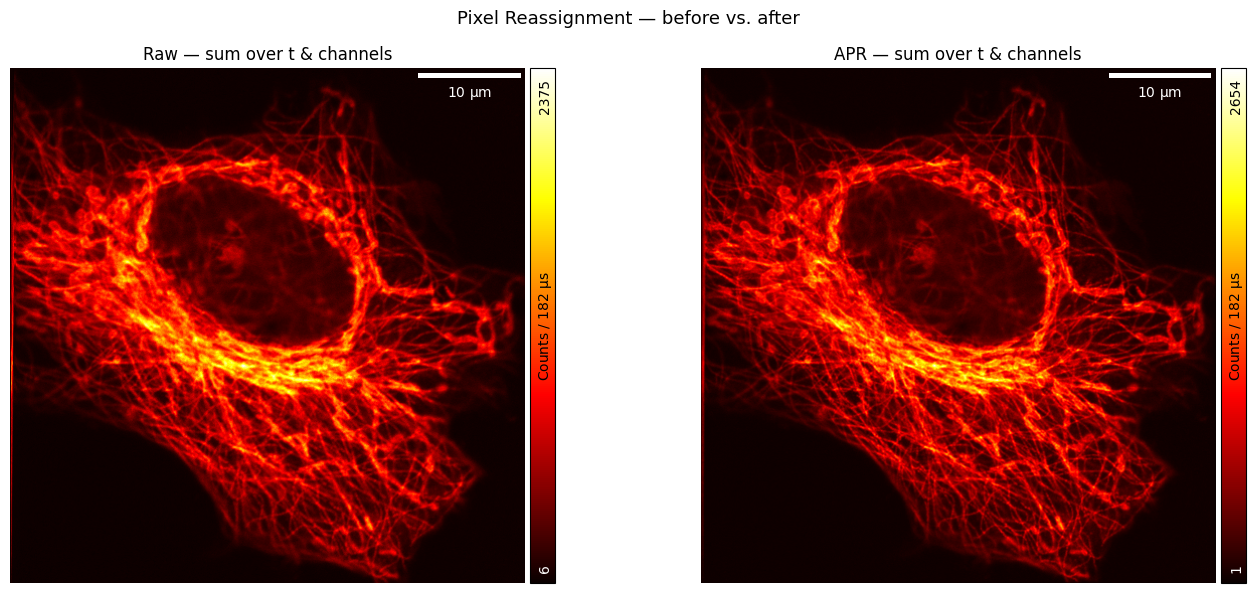

Raw image — min: 6  max: 2375
APR image — min: 1.0  max: 2654.0
Total counts — Raw: 81795747  APR: 83414760
Intensity conservation: 101.98% of raw counts retained


In [7]:
if DO_APR:
    # Sum over t_bins (axis -2) and channels (axis -1) → 2-D intensity map (y, x)
    intensity_raw = np.sum(image_4D,   axis=(-2, -1))
    intensity_apr = np.sum(reassigned, axis=(-2, -1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Use ShowImg to display images with a physical scale bar and calibrated colour scale,
    # matching the format used throughout the rest of the pipeline.
    gr.ShowImg(intensity_raw, pixel_size_x_um, pxdwelltime, fig=fig, ax=axes[0])
    axes[0].set_title("Raw — sum over t & channels")

    gr.ShowImg(intensity_apr, pixel_size_x_um, pxdwelltime, fig=fig, ax=axes[1])
    axes[1].set_title("APR — sum over t & channels")

    fig.suptitle("Pixel Reassignment — before vs. after", fontsize=13)
    fig.tight_layout()
    plt.show()

    print(f"Raw image — min: {intensity_raw.min():.0f}  max: {intensity_raw.max():.0f}")
    print(f"APR image — min: {intensity_apr.min():.1f}  max: {intensity_apr.max():.1f}")
    print(f"Total counts — Raw: {intensity_raw.sum():.0f}  APR: {intensity_apr.sum():.0f}")
    print(f"Intensity conservation: {100 * intensity_apr.sum() / intensity_raw.sum():.2f}% of raw counts retained")

else:
    print("DO_APR = False — skipping before/after comparison.")

## Sum Channels Applying Calibration Timing Shifts

Before computing phasors, the per-channel TCSPC traces are summed across all 25 SPAD channels
with the timing-skew correction applied along the time axis (`sum_channel_applying_shifts`).
This yields a single spatially-resolved decay trace per pixel.

Three variants are computed for diagnostic purposes:
- **no alignment** — raw sum with no skew correction (reference only).
- **aligned** (default) — shift-corrected sum; used for all downstream analysis.
- **reversed** — sum with shifts applied in the opposite direction; used by
  `plot_channel_skew_correction` to verify that the calibration direction is correct.

In [8]:
data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed  = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())

data_summed_rev = sum_channel_applying_shifts(
    data_input, channel_skew, axis=(), reverse_shifts=False
)[0, 0, ...]
irf_summed_rev = sum_channel_applying_shifts(
    irf_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False
)

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment  = np.sum(irf_common_delay_realigned, axis=-1)

print("data_summed :", data_summed.shape, "  (y, x, t_bins)")
print("irf_summed  :", irf_summed.shape)


Summing shifted histogram chunks: 100%|██████████| 1/1 [00:00<00:00, 1970.08it/s]


data_summed : (512, 512, 91)   (y, x, t_bins)
irf_summed  : (91,)


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Summed IRF'}, xlabel='Time bin', ylabel='Counts'>,
        <Axes: title={'center': 'Summed data'}, xlabel='Time bin', ylabel='Counts'>],
       dtype=object))

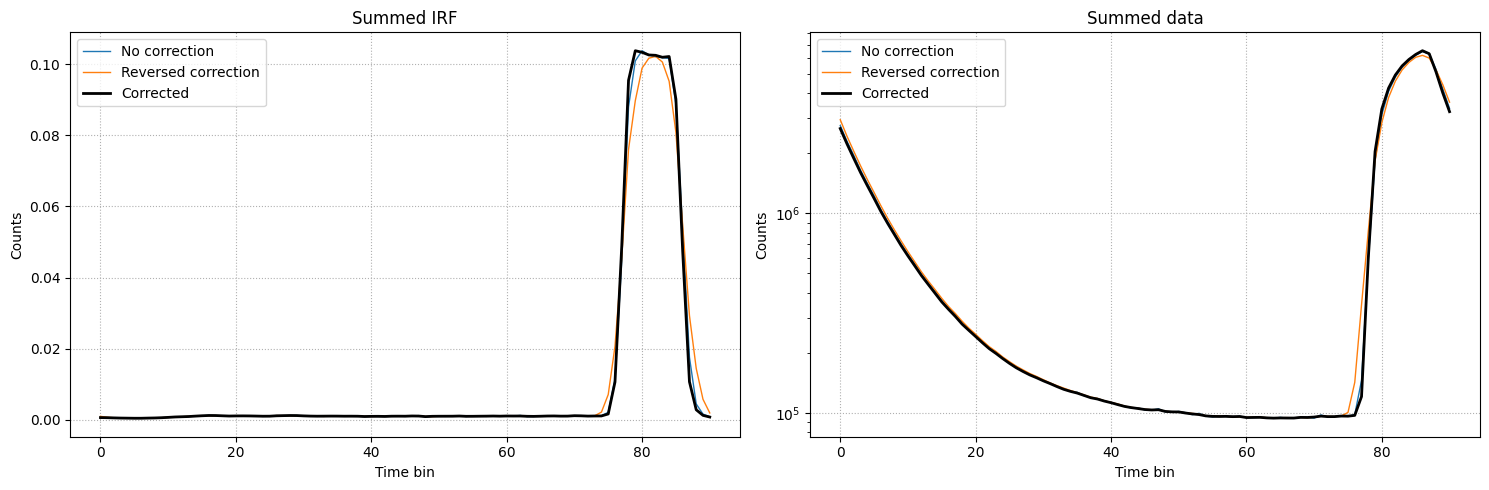

In [9]:
graph.plot_channel_skew_correction(
    irf_no_alignment=irf_summed_no_alignment,
    irf_aligned=irf_summed,
    irf_reversed=irf_summed_rev,
    data_no_alignment=data_summed_no_alignment,
    data_aligned=data_summed.sum(axis=(0, 1)),
    data_reversed=data_summed_rev.sum(axis=(0, 1)),
)


## Preview — Single-Pixel Fit

Fit the central pixel of the summed image as a sanity check before running the
full per-pixel loop.


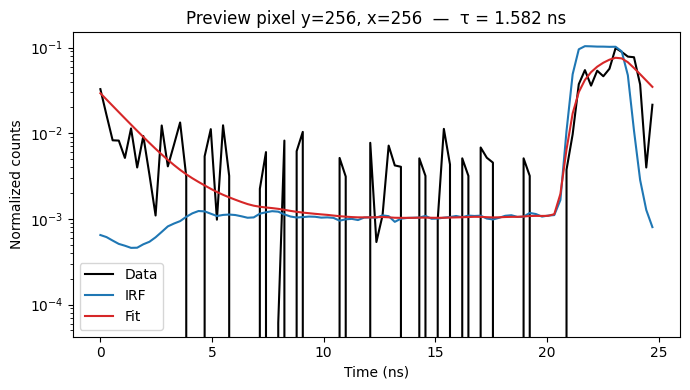

Fit result: {'C': 1.0, 'dT': -1.513823152634351, 'dT_ns': -0.4158854814929536, 'tau': 1.5824396803110192, 'params': {'C': 1.0, 'dT': -1.513823152634351, 'tau': 1.5824396803110192}, 'parameter_names': ['C', 'dT', 'tau'], 'param_names': ['C', 'dT', 'tau'], 'param_values': array([ 1.        , -1.51382315,  1.58243968]), 'param_errors': array([       nan, 0.55033686, 0.2298857 ]), 'fit': array([0.02931203, 0.02473367, 0.02087684, 0.01762899, 0.01489463,
       0.01259411, 0.01066402, 0.00904788, 0.00769768, 0.00657581,
       0.00564935, 0.00488458, 0.00425157, 0.0037335 , 0.00331549,
       0.00297825, 0.00269952, 0.00245822, 0.00224397, 0.00206111,
       0.00191081, 0.00178418, 0.00167358, 0.00157436, 0.00148856,
       0.00142613, 0.00138583, 0.00135833, 0.00133659, 0.00130994,
       0.00127577, 0.00123998, 0.00120868, 0.00118452, 0.00116494,
       0.00114605, 0.00112882, 0.00111375, 0.00109396, 0.00107444,
       0.00106172, 0.00104941, 0.00104209, 0.00104177, 0.00104125,
       0.0

In [10]:
preview_y = data_summed.shape[0] // 2
preview_x = data_summed.shape[1] // 2
preview_hist = data_summed[preview_y, preview_x, :]

preview_result, preview_cov = Alignment.perform_fit_data(
    t=t,
    data=preview_hist,
    irf=irf_summed,
    period=laser_period_ns,
    initial_tau=FIT_INITIAL_TAU,
    initial_dT=FIT_INITIAL_dT,
    initial_C=FIT_INITIAL_C,
    mode=FIT_MODE_PIXEL,
    fit_type=FIT_TYPE_PIXEL,
    force_C_normalized=True,
)

fit_preview = Alignment.fit_model_data(
    t,
    preview_result["C"],
    preview_result["dT"],
    preview_result["tau"],
    irf=irf_summed,
    period=laser_period_ns,
    mode=FIT_MODE_PIXEL,
)
fit_preview = Alignment.to_numpy_1d(fit_preview, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, preview_hist / preview_hist.sum(), label="Data",  color="black")
ax.plot(t, irf_summed   / irf_summed.sum(),   label="IRF",   color="tab:blue")
ax.plot(t, fit_preview  / fit_preview.sum(),  label="Fit",   color="tab:red")
ax.set_yscale("log")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Normalized counts")
ax.set_title(f"Preview pixel y={preview_y}, x={preview_x}  —  τ = {preview_result['tau']:.3f} ns")
ax.legend()
plt.tight_layout()
plt.show()

print("Fit result:", preview_result)


## Generate Per-Pixel Fit Maps

`Alignment.generate_fit_maps` iterates over every pixel, fits the IRF-convolved
mono-exponential model, and returns a dictionary of parameter maps
(`tau`, `dT`, `C`, `chi2`, …).


In [11]:
if not hasattr(Alignment, "generate_fit_maps"):
    raise RuntimeError(
        "The loaded brighteyes_mcs_file.alignment module does not expose "
        "'generate_fit_maps'.  Rerun the first import cell or restart the kernel."
    )

fit_maps = Alignment.generate_fit_maps(
    data=data_summed,
    irf=irf_summed,
    t=t,
    period=laser_period_ns,
    initial_tau=FIT_INITIAL_TAU,
    initial_dT=FIT_INITIAL_dT,
    initial_C=FIT_INITIAL_C,
    mode=FIT_MODE_PIXEL,
    fit_type=FIT_TYPE_PIXEL,
    force_C_normalized=True,
    n_jobs=-1,
)

fit_stack, fit_stack_names = Alignment.fit_maps_to_stack(fit_maps)
print("fit_stack shape :", fit_stack.shape)
print("fit_stack layers:", fit_stack_names)


Fitting pixel chunks: 100%|██████████| 128/128 [04:42<00:00,  2.21s/it]


fit_stack shape : (6, 512, 512)
fit_stack layers: ['C', 'dT', 'tau', 'C_err', 'dT_err', 'tau_err']


## Visualise Lifetime Maps

In [12]:
tau       = fit_maps["tau"]
intensity = data_summed.sum(axis=-1)

thresholded_tau, thresholded_intensity, lifetime_mask = graph.threshold_lifetime_map(
    tau,
    intensity=intensity,
    threshold=THRESHOLD,
)

print("Finite-tau pixels    :", np.count_nonzero(np.isfinite(tau)))
print("After-threshold pixels:", thresholded_tau.size)


Finite-tau pixels    : 262144
After-threshold pixels: 151904


/home/morlando1-iit.local/manuel/.venv/lib/python3.12/site-packages/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/morlando1-iit.local/manuel/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:727: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

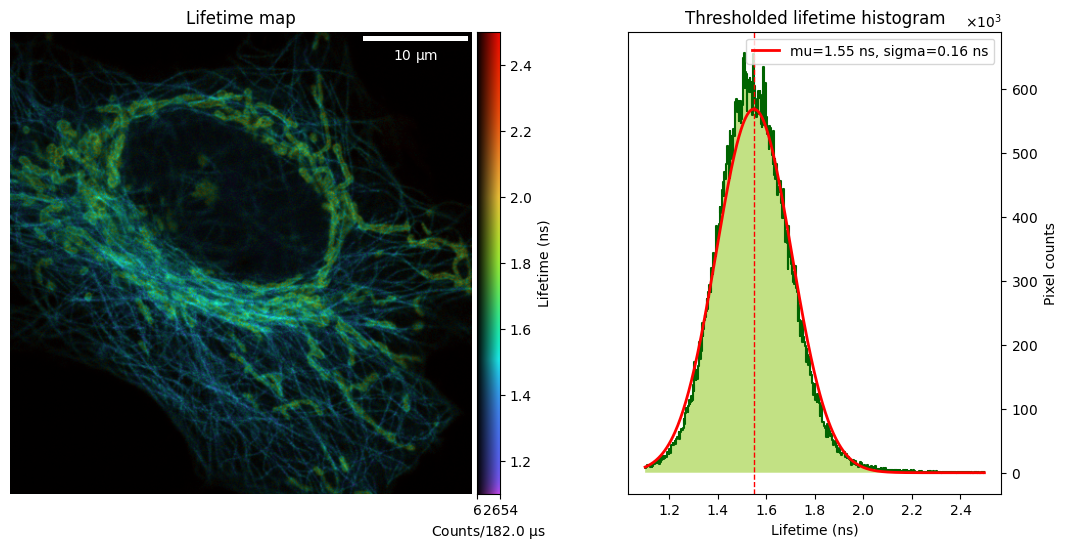

In [16]:
# ── Visualisation ─────────────────────────────────────────────────────────
THRESHOLD       = 0.05          # intensity mask threshold (fraction of max)
LIFETIME_BOUNDS = [1.1, 2.5]    # [min_ns, max_ns] for colourmap

graph.plot_lifetime_summary(
    intensity=intensity,
    lifetime=tau,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=LIFETIME_BOUNDS,
    crop=30,
    threshold=THRESHOLD,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)


/home/morlando1-iit.local/manuel/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/morlando1-iit.local/manuel/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

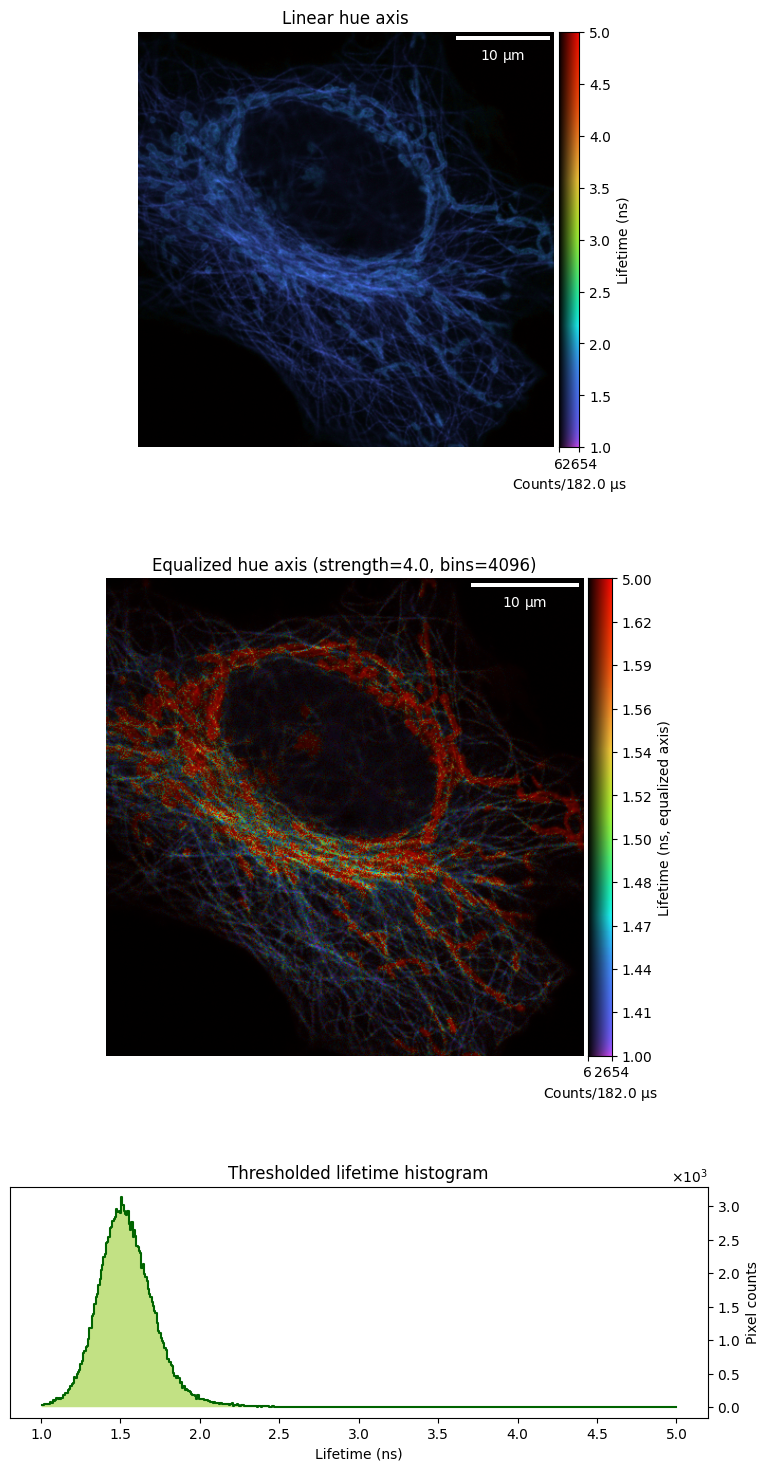

In [14]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity,
    lifetime=tau,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=LIFETIME_BOUNDS,
    crop=30,
    threshold=THRESHOLD,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)


## Optional Export

Set `EXPORT_PATH` to a valid `.h5` path to save the fit results and intensity map.
Leave it as `None` to skip.


In [15]:
EXPORT_PATH = None   # e.g. r'/path/to/output/fit_results.h5'

if EXPORT_PATH is not None:
    with h5py.File(EXPORT_PATH, "w") as hf:
        hf["intensity_map"] = intensity
        hf["tau_map"]       = tau
        hf["fit_stack"]     = fit_stack
        for name, arr in fit_maps.items():
            hf[f"fit_maps/{name}"] = arr
        hf["data_summed"]   = data_summed
        hf["irf_summed"]    = irf_summed
        hf["t_axis_ns"]     = t
    print(f"Saved → {EXPORT_PATH}")
else:
    print("Export skipped (EXPORT_PATH = None).")


Export skipped (EXPORT_PATH = None).
